In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import os

from scipy.stats import fisher_exact, spearmanr, mannwhitneyu

In [2]:
adata = sc.read("/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/Ranger_procd/ALS_SCXenium_concatenated_offset.h5ad")

if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

adata

AnnData object with n_obs × n_vars = 1841872 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'xenium_cell_id', 'sample', 'status', 'run_id', 'sd_code'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'spatial_orig'
    layers: 'counts'

# Pre-QC and filtering

Negative DNA probe count % : 0.013196040437383073
Negative decoding count % : 0.0056987639803548614


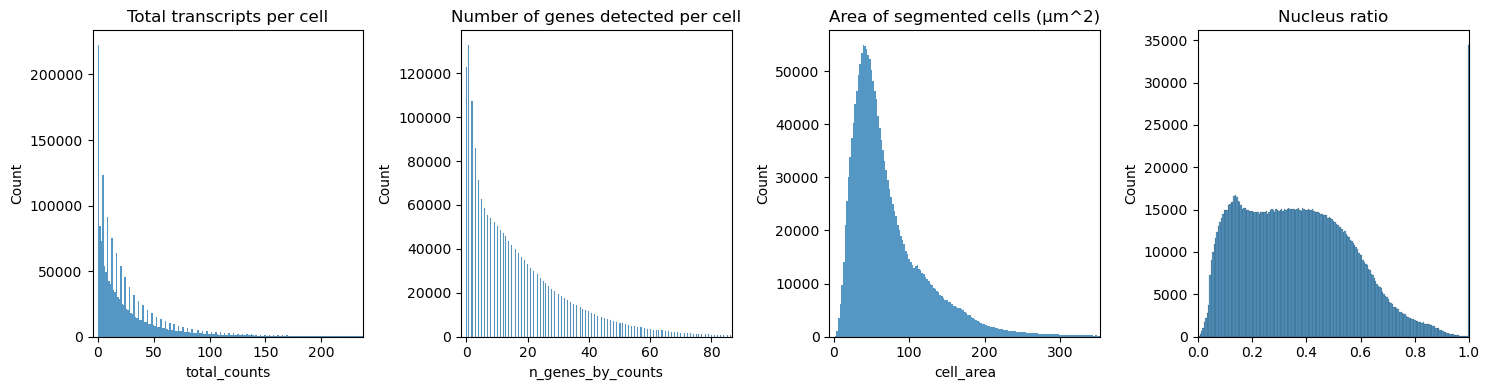

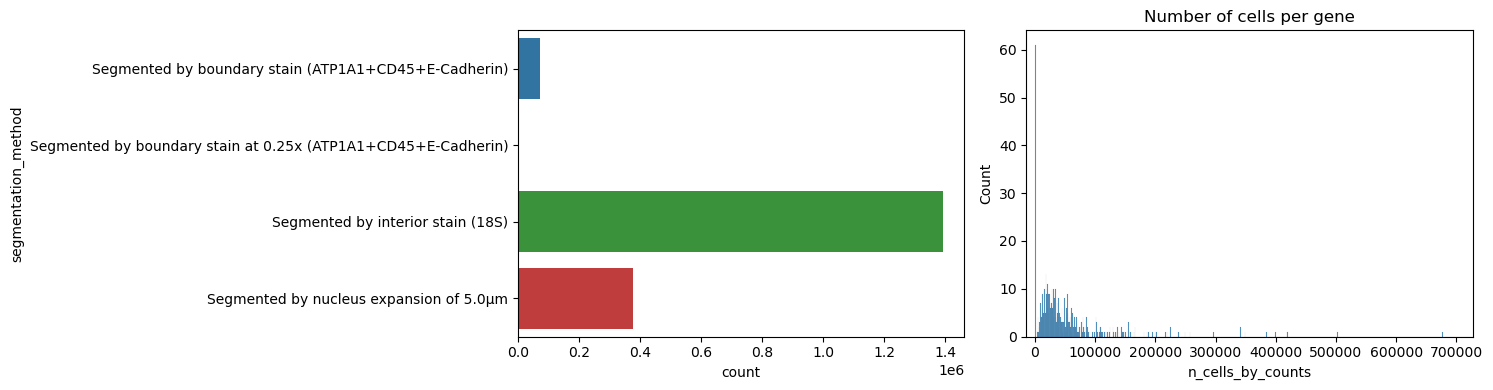

In [5]:
# ----------------------------
# helper: set xlim by quantiles
# ----------------------------
def set_xlim_by_quantile(ax, x, q_low=0.0, q_high=0.995, pad=0.02):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return
    lo, hi = np.quantile(x, [q_low, q_high])
    if hi == lo:
        return
    span = hi - lo
    ax.set_xlim(lo - pad * span, hi + pad * span)

# ----------------------------
# helper: set ylim by quantiles (optional)
# ----------------------------
def set_ylim_by_quantile(ax, y, q_low=0.0, q_high=0.995, pad=0.02):
    y = np.asarray(y)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return
    lo, hi = np.quantile(y, [q_low, q_high])
    if hi == lo:
        return
    span = hi - lo
    ax.set_ylim(lo - pad * span, hi + pad * span)

# ============================================================
# YOUR PLOT (unchanged structure) + ONLY AXES TWEAKS AFTER PLOTTING
# ============================================================

## Perform basic QC analysis á la Squidpy
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

# Calculate percentage of control probes and control codewords
cprobes = adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
cwords  = adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

# Plot distribution of total transcripts per cell, unique transcripts per cell,
# area of segmented cells and the ratio of nuclei area to their cells
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])

axs[1].set_title("Number of genes detected per cell")
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, ax=axs[1])

axs[2].set_title("Area of segmented cells (μm^2)")
sns.histplot(adata.obs["cell_area"], kde=False, ax=axs[2])

axs[3].set_title("Nucleus ratio")
ratio = adata.obs["nucleus_area"] / adata.obs["cell_area"]
sns.histplot(ratio, kde=False, ax=axs[3])

# ----------------------------
# ONLY AXES "SORTING" / RESCALING
#   - clip heavy tails so the bulk is interpretable
#   - keep nucleus ratio on [0, 1] (or quantile if you prefer)
# ----------------------------
set_xlim_by_quantile(axs[0], adata.obs["total_counts"], q_high=0.995)
set_xlim_by_quantile(axs[1], adata.obs["n_genes_by_counts"], q_high=0.995)
set_xlim_by_quantile(axs[2], adata.obs["cell_area"], q_high=0.995)

# ratio is inherently bounded; force readable axis
axs[3].set_xlim(0, 1)

# (optional) if you also want to cap the y-axis to avoid one giant bar dominating:
# for ax in axs:
#     set_ylim_by_quantile(ax, ax.patches and [p.get_height() for p in ax.patches] or [], q_high=0.995)

plt.tight_layout()

# Get the directory of the current notebook
notebook_dir = os.getcwd()

# Define the output file path in the same directory as the notebook
output_file = os.path.join(notebook_dir, "(RK)summary_histograms_Concatenatedobject.png")

# Save the figure
plt.savefig(output_file, dpi=300)
plt.show()

# Plot distribution of segmentation method
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.countplot(
    data=adata.obs,
    y="segmentation_method",
    hue="segmentation_method",
    ax=axs[0]
)

axs[1].set_title("Number of cells per gene")
sns.histplot(
    adata.var["n_cells_by_counts"],
    kde=False,
    bins=1000,
    ax=axs[1]
)

# ONLY AXES tweak for the "cells per gene" heavy tail
set_xlim_by_quantile(axs[1], adata.var["n_cells_by_counts"], q_high=0.995)

# Optional but recommended
fig.tight_layout()

# Save figure (Nature-safe defaults)
fig.savefig(
    "(RK)Concatenatedobject_largecells_seg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


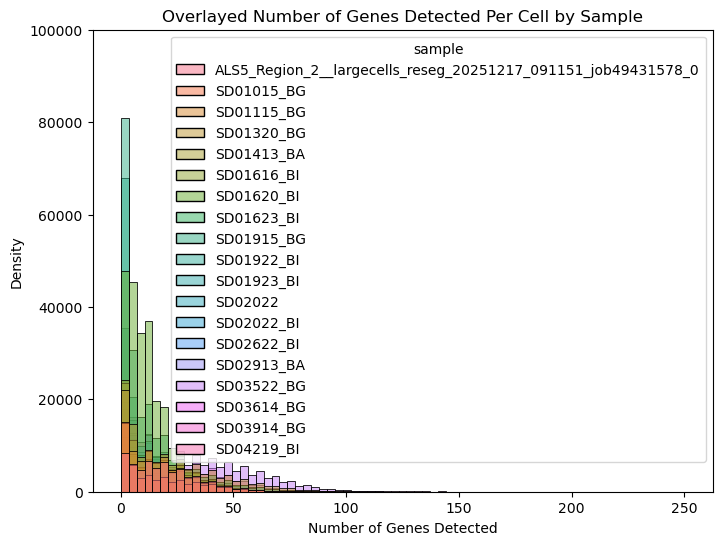

In [15]:
plt.figure(figsize=(8, 6))

# Plot the distribution of 'n_genes_by_counts' for each sample
sns.histplot(
    data=adata.obs,
    x="n_genes_by_counts",
    hue="sample",  # Use the sample label to differentiate the samples
    #element="step",  # Use step to create outlined histograms for better overlay visualization
    kde=False,
    stat="count", 
    binwidth=3.5, #  Normalize the histogram
    common_norm=True  # Each distribution is normalized independently
)

# Add title and labels
# Set x-axis limits from 0 to 1300
plt.ylim(0, 100000)
plt.title("Overlayed Number of Genes Detected Per Cell by Sample")
plt.xlabel("Number of Genes Detected")
plt.ylabel("Density")


# Save the figure with high DPI using plt.gcf()
plt.gcf().savefig('(RK)n_genes_by_counts_merged.png', dpi=300, format='png')
# Display the plot
plt.show()

# Filtering

Filtered adata: (775942, 538)


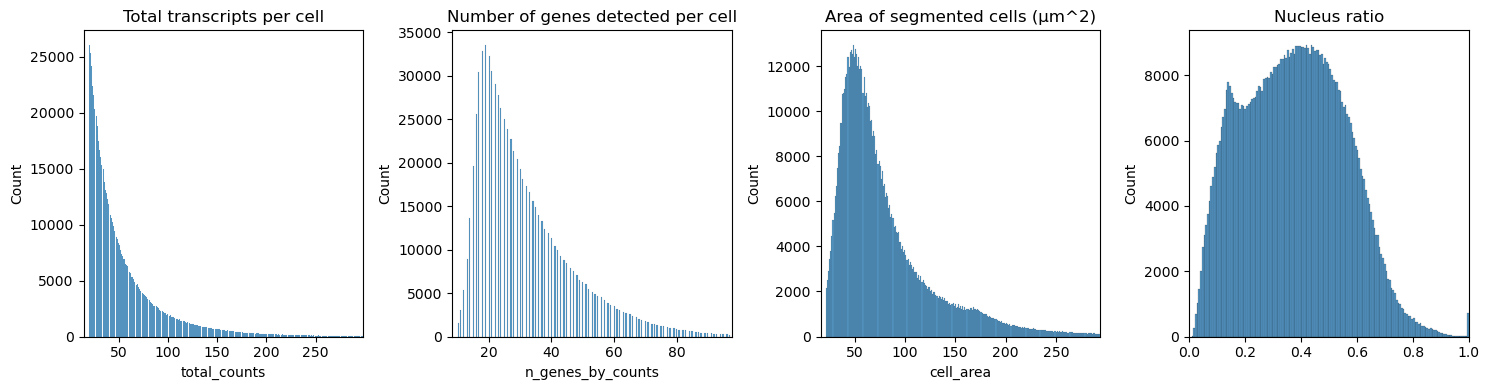

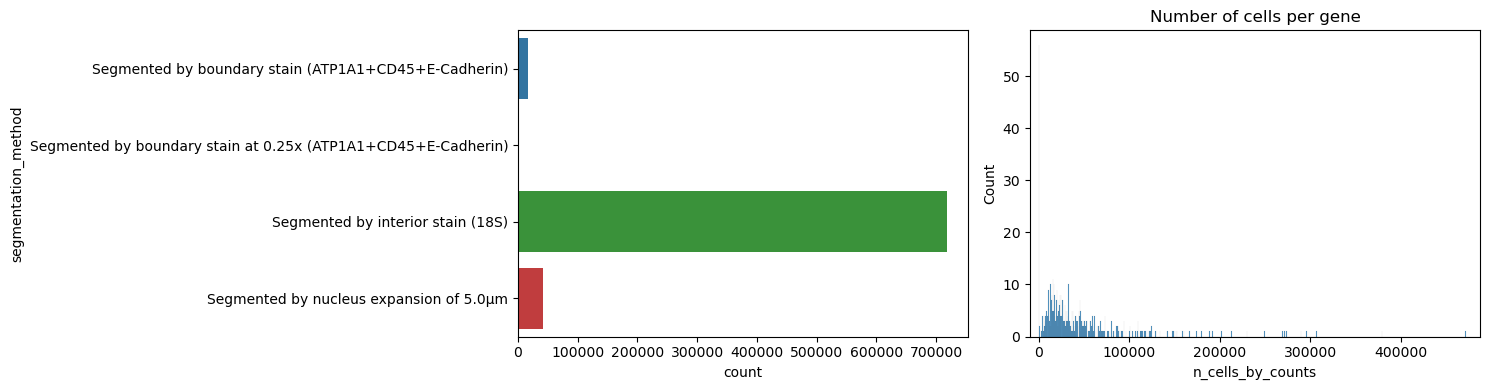

In [16]:
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import os

# =========================
# CONFIG: starting thresholds
# =========================
MIN_TOTAL_COUNTS = 20
MIN_N_GENES      = 10

# optional morphology / ratio guards (set to None to disable)
CLIP_AREA_Q = (0.01, 0.99)   # keep cells within 1st–99th percentile area
RATIO_XLIM  = (0.0, 1.0)     # keep plotting on [0,1]; filtering uses quantiles below
CLIP_RATIO_Q = None          # e.g. (0.001, 0.999) to drop extreme ratios, or None to disable

# gene filters
MIN_GENE_CELLS  = 20
MIN_GENE_COUNTS = 10   # set to 0 to disable

# histogram axis clipping for readability
HIST_QHI = 0.995

# =========================
# HELPERS: axes-only tweaks
# =========================
def set_xlim_by_quantile(ax, x, q_low=0.0, q_high=0.995, pad=0.02):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return
    lo, hi = np.quantile(x, [q_low, q_high])
    if hi == lo:
        return
    span = hi - lo
    ax.set_xlim(lo - pad * span, hi + pad * span)

# =========================
# 1) Cell-level filtering
# =========================
adata_f = adata.copy()

# ensure QC fields exist
sc.pp.calculate_qc_metrics(adata_f, percent_top=(10, 20, 50, 150), inplace=True)

# base QC filters
sc.pp.filter_cells(adata_f, min_counts=MIN_TOTAL_COUNTS)
sc.pp.filter_cells(adata_f, min_genes=MIN_N_GENES)

# optional: filter by cell_area quantiles
if CLIP_AREA_Q is not None and "cell_area" in adata_f.obs:
    lo, hi = np.quantile(adata_f.obs["cell_area"].values[np.isfinite(adata_f.obs["cell_area"].values)], CLIP_AREA_Q)
    m_area = np.isfinite(adata_f.obs["cell_area"].values) & (adata_f.obs["cell_area"].values >= lo) & (adata_f.obs["cell_area"].values <= hi)
    adata_f = adata_f[m_area].copy()

# optional: filter by nucleus ratio quantiles
if CLIP_RATIO_Q is not None and ("nucleus_area" in adata_f.obs) and ("cell_area" in adata_f.obs):
    ratio = (adata_f.obs["nucleus_area"] / adata_f.obs["cell_area"]).values
    ratio = ratio[np.isfinite(ratio)]
    if ratio.size > 0:
        lo, hi = np.quantile(ratio, CLIP_RATIO_Q)
        r = (adata_f.obs["nucleus_area"] / adata_f.obs["cell_area"]).values
        m_ratio = np.isfinite(r) & (r >= lo) & (r <= hi)
        adata_f = adata_f[m_ratio].copy()

# recompute QC after cell filtering (keeps obs QC fields consistent)
sc.pp.calculate_qc_metrics(adata_f, percent_top=(10, 20, 50, 150), inplace=True)

# =========================
# 2) Gene-level filtering
# =========================
if MIN_GENE_COUNTS and MIN_GENE_COUNTS > 0:
    sc.pp.filter_genes(adata_f, min_counts=MIN_GENE_COUNTS)
sc.pp.filter_genes(adata_f, min_cells=MIN_GENE_CELLS)

# recompute QC after gene filtering
sc.pp.calculate_qc_metrics(adata_f, percent_top=(10, 20, 50, 150), inplace=True)

print("Filtered adata:", adata_f.shape)

# =========================
# 3) Re-plot histograms (same structure; axes clipped only)
# =========================
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(adata_f.obs["total_counts"], kde=False, ax=axs[0])
set_xlim_by_quantile(axs[0], adata_f.obs["total_counts"], q_high=HIST_QHI)

axs[1].set_title("Number of genes detected per cell")
sns.histplot(adata_f.obs["n_genes_by_counts"], kde=False, ax=axs[1])
set_xlim_by_quantile(axs[1], adata_f.obs["n_genes_by_counts"], q_high=HIST_QHI)

axs[2].set_title("Area of segmented cells (μm^2)")
sns.histplot(adata_f.obs["cell_area"], kde=False, ax=axs[2])
set_xlim_by_quantile(axs[2], adata_f.obs["cell_area"], q_high=HIST_QHI)

axs[3].set_title("Nucleus ratio")
ratio_f = adata_f.obs["nucleus_area"] / adata_f.obs["cell_area"]
sns.histplot(ratio_f, kde=False, ax=axs[3])
axs[3].set_xlim(*RATIO_XLIM)

plt.tight_layout()

# save next to notebook (optional)
notebook_dir = os.getcwd()
output_file = os.path.join(notebook_dir, "(RK)summary_histograms_after_filtering.png")
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 4) Segmentation + cells-per-gene (same structure; axes clipped only)
# =========================
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.countplot(
    data=adata_f.obs,
    y="segmentation_method",
    hue="segmentation_method",
    ax=axs[0]
)

axs[1].set_title("Number of cells per gene")
sns.histplot(
    adata_f.var["n_cells_by_counts"],
    kde=False,
    bins=1000,
    ax=axs[1]
)
set_xlim_by_quantile(axs[1], adata_f.var["n_cells_by_counts"], q_high=HIST_QHI)

fig.tight_layout()

fig.savefig(
    "(RK)Concatenatedobject_largecells_seg_after_filtering.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [17]:
# write post-filtering object back into a new AnnData (or overwrite adata)
adata_post = adata_f.copy()

# optional: free memory
del adata_f

print("adata_post:", adata_post.shape)

adata_post: (775942, 538)


In [18]:
adata_post

AnnData object with n_obs × n_vars = 775942 × 538
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'xenium_cell_id', 'sample', 'status', 'run_id', 'sd_code', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    obsm: 'spatial', 'spatial_orig'
    layers: 'counts'

In [19]:
adata_post.write("/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/Ranger_procd/ALS_SCXenium_concatenated_offset_postQC.h5ad")